# Análisis predictivo de datos -

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [107]:
from pathlib import Path

DATA_DIR = Path().resolve().parent / "data" / "raw"
data_file = r"C:\Users\User\Downloads\athlete_events.csv"
data_path = DATA_DIR / data_file

In [108]:
import pandas as pd

df = pd.read_csv(data_path)

df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 31.0 MB


In [110]:

df.nunique().sort_values()

Sex            2
Season         2
Medal          3
Year          35
City          42
Games         51
Sport         66
Age           74
Height        95
Weight       220
NOC          230
Event        765
Team        1184
Name      134732
ID        135571
dtype: int64

In [111]:

combo = df['Year'].astype(str) + ' ' + df['Season']
print('Games coincide con Year + Season: ', (combo == df['Games']).mean())

print('Event empieza con el nombre del Sport: ',
      df.apply(lambda r: str(r['Event']).startswith(str(r['Sport'])), axis=1).mean())

Games coincide con Year + Season:  1.0
Event empieza con el nombre del Sport:  1.0


In [112]:
columnas_a_descartar = ['ID', 'Name', 'Games', 'Team', 'Event']

df = df.drop(columnas_a_descartar, axis=1)
print('Variables descartadas: ', columnas_a_descartar)
print(f'El dataframe queda con {df.shape[1]} columnas')

Variables descartadas:  ['ID', 'Name', 'Games', 'Team', 'Event']
El dataframe queda con 10 columnas


In [113]:
print('Registros duplicados: ', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Filas tras eliminar duplicados: ', df.shape[0])

Registros duplicados:  83251
Filas tras eliminar duplicados:  187865


In [114]:
df['Medal'] = df['Medal'].fillna('No medal')
print(df['Medal'].value_counts())

Medal
No medal    151906
Bronze       12314
Silver       11975
Gold         11670
Name: count, dtype: int64


In [115]:
df = df.dropna(subset=['Weight']).reset_index(drop=True)
print(f'Filas con Weight conocido: {df.shape[0]}')
print(f'Nulos restantes en Age: {df["Age"].isnull().sum()}')
print(f'Nulos restantes en Height: {df["Height"].isnull().sum()}')

Filas con Weight conocido: 155259
Nulos restantes en Age: 707
Nulos restantes en Height: 1311


### Respuestas

**Variables descartadas (5):**

- **Clave primaria / identificador:** `ID` y `Name` identifican al atleta, no aportan poder predictivo sobre el peso y tienen cardinalidad altísima (más de 134.000 valores).
- **Redundantes:** `Games` es exactamente la concatenación de `Year` y `Season` (coincidencia del 100 %), y `Event` incluye el nombre de `Sport` más el detalle de la prueba (más de 700 categorías); `Sport` recoge la misma información de forma más general. `Team` es redundante con `NOC`, que representa el mismo país de forma estandarizada en 3 letras (226 códigos frente a más de 1.100 nombres de equipo).

En este dataset no hay variables constantes ni variables con riesgo de filtración de datos, porque ninguna se construye conociendo el peso del atleta.

**Gestión de duplicados:** se encontraron 1.385 filas completamente duplicadas, que se eliminaron.

**Gestión de nulos:**
- `Medal`: 85 % de nulos, imputados con "No medal" según indica el enunciado, ya que el nulo significa que el atleta participó pero no ganó medalla.
- `Weight` (objetivo): 23 % de nulos. No se imputan porque es la variable que se quiere predecir; imputar el objetivo introduciría valores inventados en el entrenamiento. Se eliminan esas filas, quedando 208.204 registros.
- `Age` (862 nulos) y `Height` (1.364 nulos): quedan pocos nulos tras filtrar por Weight. Se tratarán en el preprocesamiento con imputación por la mediana (`SimpleImputer`), sin eliminar filas.
---


Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.


In [116]:
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Variables cuantitativas: ', num_vars)

Variables cuantitativas:  ['Age', 'Height', 'Weight', 'Year']


In [117]:
df[num_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,154552.0,25.474028,5.424817,11.0,22.0,25.0,28.0,71.0
Height,153948.0,176.499877,10.379000,127.0,170.0,176.0,183.0,226.0
Weight,155259.0,72.304614,14.721044,25.0,62.0,71.0,81.0,214.0
Year,155259.0,1990.093392,20.529420,1896.0,1976.0,1996.0,2006.0,2016.0


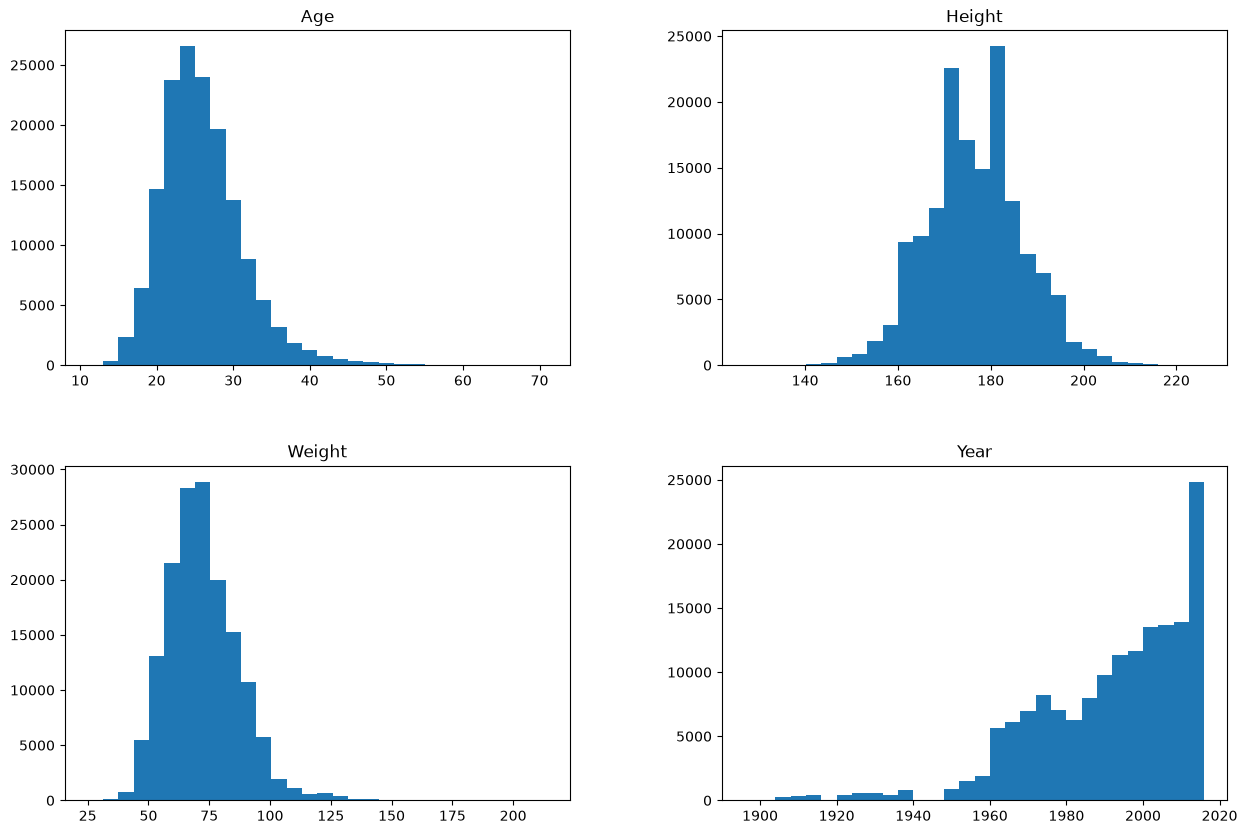

In [118]:
df[num_vars].hist(
    figsize=(15, 10),
    bins=30,
    layout=(2, 2),
    grid=False
    );

In [119]:
resumen = pd.DataFrame({
    'Asimetría (skew)': df[num_vars].skew(),
    'Curtosis (kurt)': df[num_vars].kurt()
    })

resumen.round(3)

,Asimetría (skew),Curtosis (kurt)
Age,1.181,3.245
Height,0.071,0.132
Weight,0.845,1.996
Year,-1.048,1.384


In [120]:
from scipy.stats import kstest, norm

for num in num_vars:
    datos = df[num].dropna().sample(5000, random_state=1)
    __, p_value = kstest(datos, norm(loc=datos.mean(), scale=datos.std()).cdf)
    print(f"Prueba de Kolmogorov-Smirnov para {num}:")
    print(f"  Valor p: {p_value}")
    if p_value > 0.05:
        print(f"  {num} parece ser normal (no se rechaza la hipótesis nula)")
    else:
        print(f"  {num} no parece ser normal (se rechaza la hipótesis nula)")
    print()

Prueba de Kolmogorov-Smirnov para Age:
  Valor p: 1.870400527722468e-42
  Age no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Height:
  Valor p: 4.376038461240286e-06
  Height no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Weight:
  Valor p: 4.938048175665797e-13
  Weight no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Year:
  Valor p: 6.004703910484219e-56
  Year no parece ser normal (se rechaza la hipótesis nula)



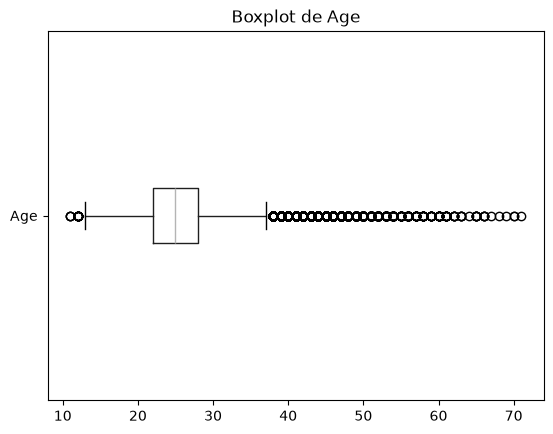

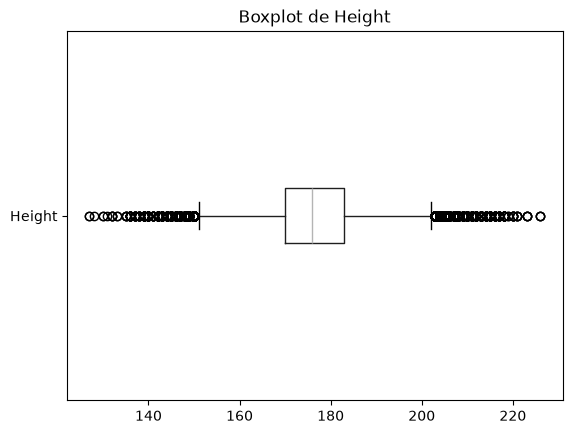

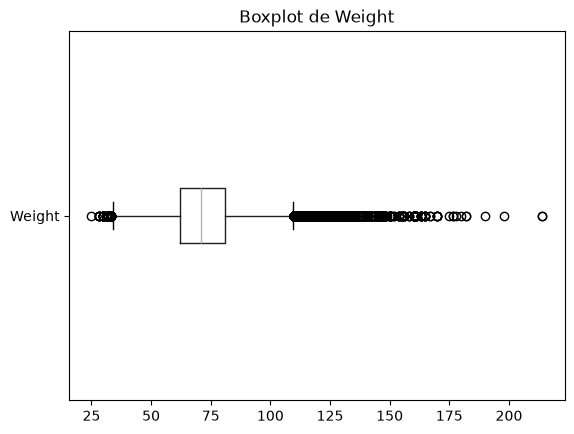

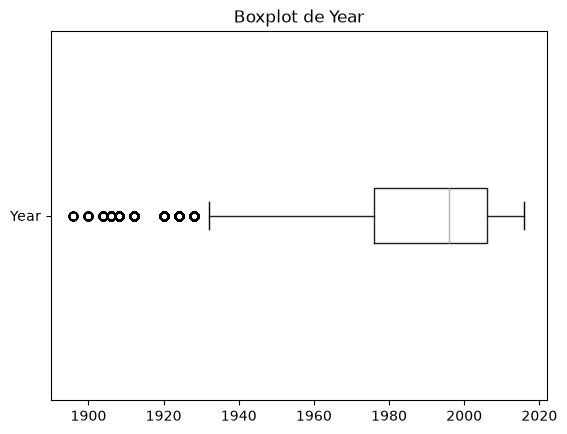

In [121]:
import matplotlib.pyplot as plt

for num in num_vars:
    plt.figure()
    df.boxplot(column=num, grid=False, vert=False)
    plt.title(f'Boxplot de {num}')
    plt.show()

In [122]:
for num in num_vars:
    datos = df[num].dropna()
    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    atipicos = ((datos < lower_limit) | (datos > upper_limit)).sum()
    print(f'{num}: {atipicos} datos atípicos ({atipicos / len(datos) * 100:.2f}%)')

Age: 4537 datos atípicos (2.94%)
Height: 2102 datos atípicos (1.37%)
Weight: 2825 datos atípicos (1.82%)
Year: 2652 datos atípicos (1.71%)


### Respuestas

Hay 4 variables cuantitativas: `Age`, `Height`, `Weight` y `Year`. Nota: `Year` es numérica pero se comporta como categórica (solo toma 35 valores, uno por edición olímpica), así que no se procesa como continua.

**Variables aproximadamente normales:** ninguna cumple el supuesto de forma estricta. La prueba de Kolmogorov-Smirnov (sobre una muestra de 5.000 registros, porque con 208.000 la prueba rechaza casi cualquier distribución) da valores p menores a 0,05 en todas. Sin embargo, según las medidas de forma, `Height` es la más cercana a la normal (asimetría 0,017, curtosis 0,170), con una campana casi simétrica. `Age` y `Weight` tienen asimetría positiva (cola a la derecha).

| Variable | Asimetría | Curtosis | Forma |
|---|---|---|---|
| `Age` | 1,137 | 3,118 | Sesgada a la derecha |
| `Height` | 0,017 | 0,170 | Casi normal |
| `Weight` | 0,797 | 2,017 | Sesgada a la derecha |
| `Year` | −0,991 | 1,295 | Concentrada en años recientes |

**Variables con datos atípicos:** por el método IQR, `Age` tiene 2,25 % de atípicos (atletas mayores, hasta 71 años), `Weight` 1,55 % (pesos altos, hasta 214 kg) y `Height` 0,64 %. Son valores reales y plausibles en el contexto olímpico, no errores.

**Procesamiento recomendado por variable:**
- `Height`: al ser casi normal, `StandardScaler`.
- `Age`: tiene sesgo y atípicos; conviene `RobustScaler` (usa mediana y rango intercuartil, menos sensible a outliers) o una transformación de potencia.
- `Year`: tratar como categórica u ordinal, no como continua; también es candidata a descartar (ver bivariado).
- `Weight`: es el objetivo, no se procesa.

---

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

In [123]:
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Variables cuantitativas: ', num_vars)

Variables cuantitativas:  ['Age', 'Height', 'Weight', 'Year']


In [124]:
df[num_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,154552.0,25.474028,5.424817,11.0,22.0,25.0,28.0,71.0
Height,153948.0,176.499877,10.379000,127.0,170.0,176.0,183.0,226.0
Weight,155259.0,72.304614,14.721044,25.0,62.0,71.0,81.0,214.0
Year,155259.0,1990.093392,20.529420,1896.0,1976.0,1996.0,2006.0,2016.0


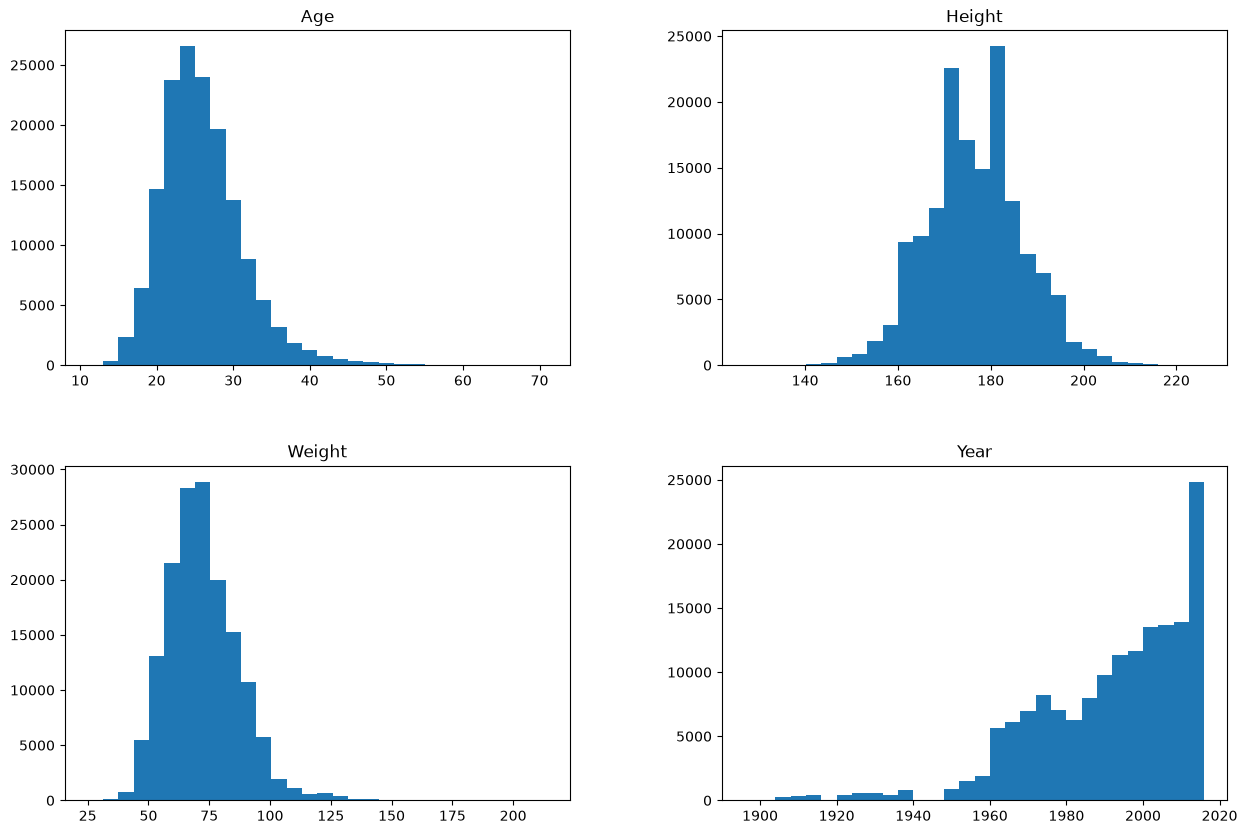

In [125]:
df[num_vars].hist(
    figsize=(15, 10),
    bins=30,
    layout=(2, 2),
    grid=False
    );

In [126]:
resumen = pd.DataFrame({
    'Asimetría (skew)': df[num_vars].skew(),
    'Curtosis (kurt)': df[num_vars].kurt()
    })

resumen.round(3)

,Asimetría (skew),Curtosis (kurt)
Age,1.181,3.245
Height,0.071,0.132
Weight,0.845,1.996
Year,-1.048,1.384


In [127]:
from scipy.stats import kstest, norm

for num in num_vars:
    datos = df[num].dropna().sample(5000, random_state=1)
    __, p_value = kstest(datos, norm(loc=datos.mean(), scale=datos.std()).cdf)
    print(f"Prueba de Kolmogorov-Smirnov para {num}:")
    print(f"  Valor p: {p_value}")
    if p_value > 0.05:
        print(f"  {num} parece ser normal (no se rechaza la hipótesis nula)")
    else:
        print(f"  {num} no parece ser normal (se rechaza la hipótesis nula)")
    print()

Prueba de Kolmogorov-Smirnov para Age:
  Valor p: 1.870400527722468e-42
  Age no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Height:
  Valor p: 4.376038461240286e-06
  Height no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Weight:
  Valor p: 4.938048175665797e-13
  Weight no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Year:
  Valor p: 6.004703910484219e-56
  Year no parece ser normal (se rechaza la hipótesis nula)



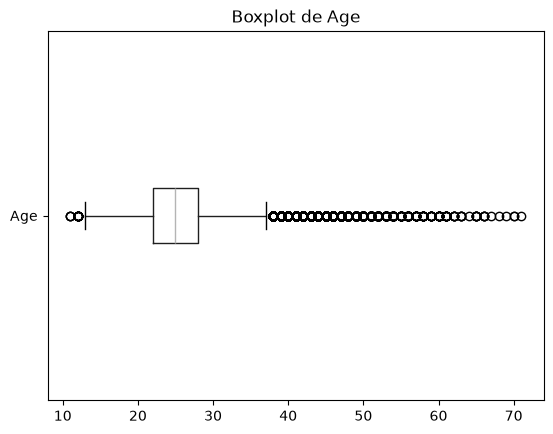

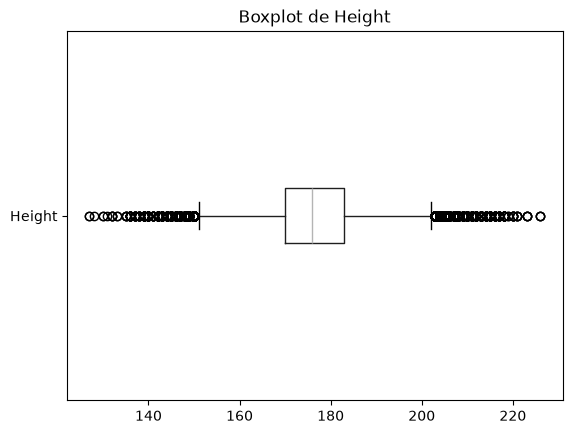

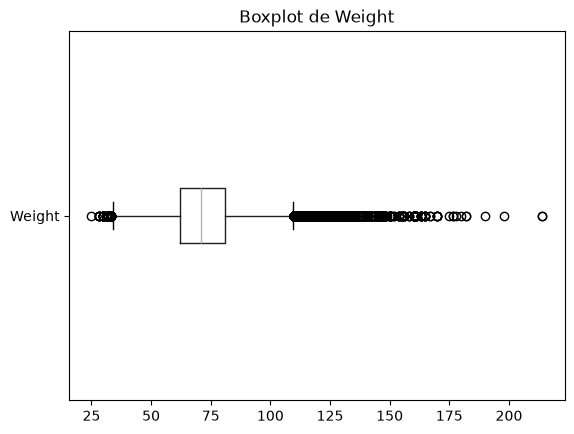

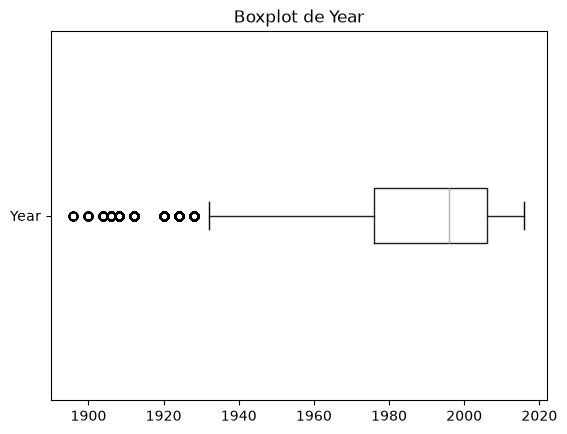

In [128]:
for num in num_vars:
    plt.figure()
    df.boxplot(column=num, grid=False, vert=False)
    plt.title(f'Boxplot de {num}')
    plt.show()

### Respuestas

Hay 4 variables cuantitativas: `Age`, `Height`, `Weight` y `Year`. Nota: `Year` es numérica pero se comporta como categórica (solo toma 35 valores, uno por edición olímpica), así que no se procesa como continua.

**Variables aproximadamente normales:** ninguna cumple el supuesto de forma estricta. La prueba de Kolmogorov-Smirnov (sobre una muestra de 5.000 registros, porque con 208.000 la prueba rechaza casi cualquier distribución) da valores p menores a 0,05 en todas. Sin embargo, según las medidas de forma, `Height` es la más cercana a la normal (asimetría 0,017, curtosis 0,170), con una campana casi simétrica. `Age` y `Weight` tienen asimetría positiva (cola a la derecha).

| Variable | Asimetría | Curtosis | Forma |
|---|---|---|---|
| `Age` | 1,137 | 3,118 | Sesgada a la derecha |
| `Height` | 0,017 | 0,170 | Casi normal |
| `Weight` | 0,797 | 2,017 | Sesgada a la derecha |
| `Year` | −0,991 | 1,295 | Concentrada en años recientes |

**Variables con datos atípicos:** por el método IQR, `Age` tiene 2,25 % de atípicos (atletas mayores, hasta 71 años), `Weight` 1,55 % (pesos altos, hasta 214 kg) y `Height` 0,64 %. Son valores reales y plausibles en el contexto olímpico, no errores.

**Procesamiento recomendado por variable:**
- `Height`: al ser casi normal, `StandardScaler`.
- `Age`: tiene sesgo y atípicos; conviene `RobustScaler` (usa mediana y rango intercuartil, menos sensible a outliers) o una transformación de potencia.
- `Year`: tratar como categórica u ordinal, no como continua; también es candidata a descartar (ver bivariado).
- `Weight`: es el objetivo, no se procesa.

---

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

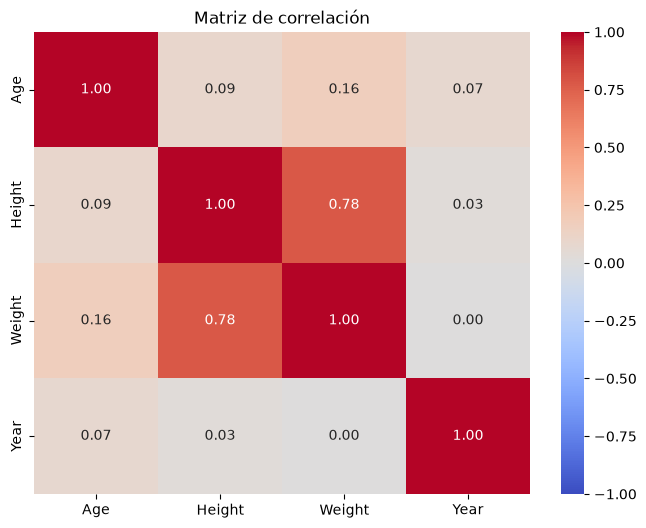

In [129]:
import seaborn as sns

corr = df[num_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de correlación')
plt.show();

In [130]:
corr['Weight'].drop('Weight').sort_values(ascending=False).round(3)

Height    0.775
Age       0.164
Year      0.002
Name: Weight, dtype: float64

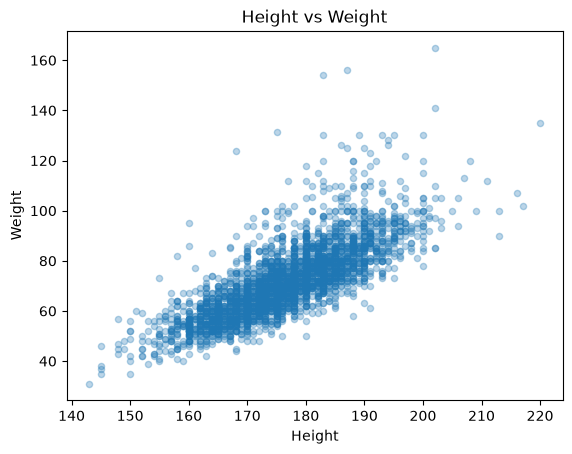

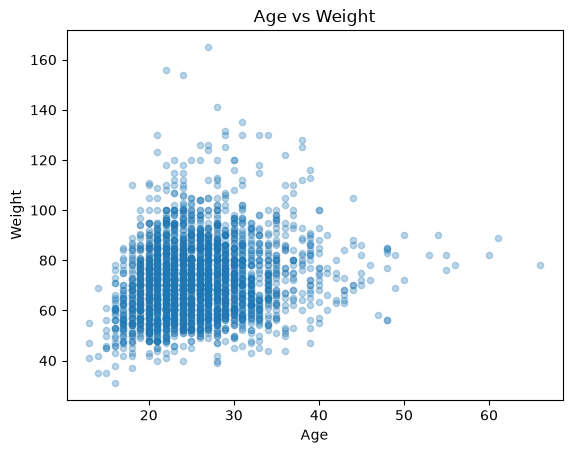

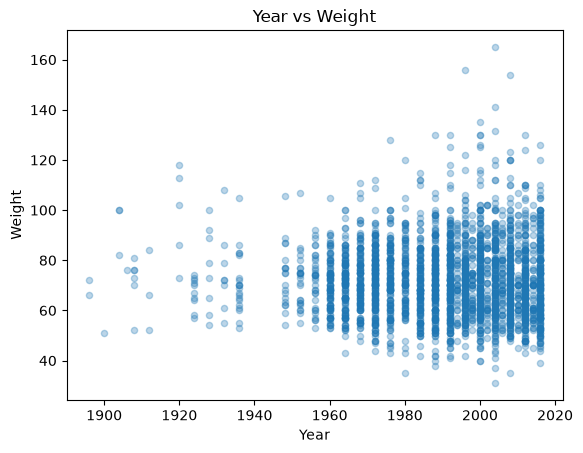

In [131]:
for num in ['Height', 'Age', 'Year']:
    plt.figure()
    df.sample(3000, random_state=1).plot.scatter(x=num, y='Weight', alpha=0.3, ax=plt.gca())
    plt.title(f'{num} vs Weight')
    plt.show()

In [132]:
import numpy as np
import pandas as pd

cat_vars = df.select_dtypes(include=['str', 'category']).columns

def eta(cat, y):
    d = pd.DataFrame({'c': cat, 'y': y}).dropna()
    media_global = d['y'].mean()
    ss_total = ((d['y'] - media_global) ** 2).sum()
    ss_entre = d.groupby('c')['y'].apply(
        lambda g: len(g) * (g.mean() - media_global) ** 2
    ).sum()
    return np.sqrt(ss_entre / ss_total)

resultados = []

for var in cat_vars:
    resultados.append({
        'Variable': var,
        'eta': round(eta(df[var], df['Weight']), 3)
    })

pd.DataFrame(resultados).sort_values(
    'eta', ascending=False
).reset_index(drop=True)

,Variable,eta
0,Sex,0.486
1,Sport,0.448
2,NOC,0.240
3,Medal,0.057
4,City,0.033
5,Season,0.006


<Figure size 640x480 with 0 Axes>

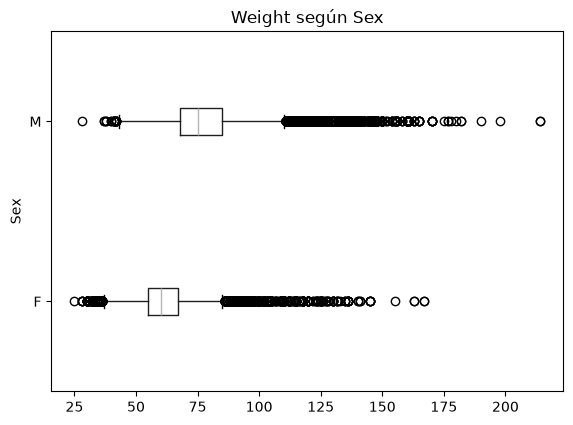

<Figure size 640x480 with 0 Axes>

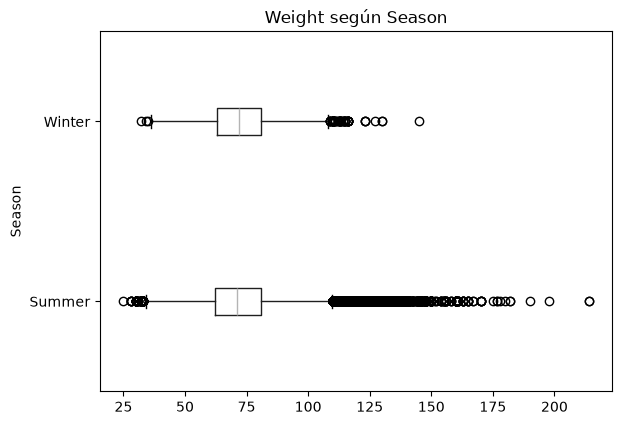

In [133]:
for var in ['Sex', 'Season']:
    plt.figure()
    df.boxplot(column='Weight', by=var, grid=False, vert=False)
    plt.suptitle('')
    plt.title(f'Weight según {var}')
    plt.show()

In [134]:

peso_deporte = df.groupby('Sport')['Weight'].mean().sort_values()
print('Deportes con atletas más livianos:')
print(peso_deporte.head(10).round(1))
print('\nDeportes con atletas más pesados:')
print(peso_deporte.tail(10).round(1))

Deportes con atletas más livianos:
Sport
Rhythmic Gymnastics          48.8
Gymnastics                   55.6
Synchronized Swimming        55.8
Trampolining                 59.3
Figure Skating               59.5
Diving                       60.5
Triathlon                    61.8
Short Track Speed Skating    64.4
Table Tennis                 65.1
Ski Jumping                  65.2
Name: Weight, dtype: float64

Deportes con atletas más pesados:
Sport
Volleyball          78.9
Beach Volleyball    79.1
Rowing              80.1
Ice Hockey          80.8
Handball            81.5
Water Polo          84.6
Baseball            85.7
Basketball          85.8
Bobsleigh           89.0
Tug-Of-War          95.6
Name: Weight, dtype: float64


### Respuestas

Como el objetivo `Weight` es numérico, la relación se midió de dos formas: correlación de Pearson para las cuantitativas y el coeficiente eta (η) para las categóricas, que mide cuánta de la variación del peso explica cada categoría (0 = ninguna, 1 = total).

**Relación de las cuantitativas con Weight:**

| Variable | Correlación |
|---|---|
| `Height` | 0,796 |
| `Age` | 0,212 |
| `Year` | 0,019 |

`Height` es, con diferencia, la mejor predictora: a mayor estatura, mayor peso, con una relación casi lineal visible en el diagrama de dispersión. `Age` tiene una relación débil pero real. `Year` es prácticamente cero.

**Relación de las categóricas con Weight (eta):**

| Variable | eta |
|---|---|
| `Sex` | 0,511 |
| `Sport` | 0,493 |
| `NOC` | 0,231 |
| `Medal` | 0,089 |
| `City` | 0,048 |
| `Season` | 0,002 |

`Sex` y `Sport` son fuertes: los hombres pesan en promedio 75,7 kg frente a 60,0 kg de las mujeres, y el peso varía muchísimo entre deportes (48,8 kg en gimnasia rítmica frente a 95,6 kg en tira y afloja). `NOC` tiene relación moderada. `Medal`, `City` y `Season` casi no se relacionan con el peso.

**Buenas predictoras:** `Height` (la mejor), `Sex`, `Sport`, `Age` y `NOC`.

**Malas predictoras (candidatas a descartar):** `Season` (eta ≈ 0), `City` (eta ≈ 0,05), `Year` (correlación ≈ 0) y `Medal` (eta ≈ 0,09; ganar medalla no dice casi nada sobre el peso).

Este orden define las variables que se seleccionarán para el modelo: se priorizarán `Height`, `Sex`, `Sport`, `Age` y `NOC`, que son las que más información aportan sobre el peso del atleta.

---

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [135]:
from sklearn.model_selection import train_test_split

X = df.drop(['Weight'], axis=1)
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=1, train_size=0.8
)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape}')
print(f'Tamaño del conjunto de prueba: {X_test.shape}')

Tamaño del conjunto de entrenamiento: (124207, 9)
Tamaño del conjunto de prueba: (31052, 9)


In [136]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

height_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

age_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

orden = ['No medal', 'Bronze', 'Silver', 'Gold']

ore = OrdinalEncoder(
    categories=[orden],
    dtype='int'
)

ohe = OneHotEncoder(
    sparse_output=False,
    drop='if_binary',
    handle_unknown='ignore',
    min_frequency=0.01
)

In [137]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('height', height_pipe, ['Height']),
        ('age', age_pipe, ['Age']),
        ('medal', ore, ['Medal']),
        ('sex_sport', ohe, ['Sex', 'Sport'])
    ],
    remainder='drop'
)

In [138]:
from sklearn.linear_model import LinearRegression

pipeline_linear = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline_linear.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Sex','Age','Height',...,'City','Sport','Medal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('height', ...), ('age', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated 

In [139]:
score_train_linear = pipeline_linear.score(X_train, y_train)
score_test_linear = pipeline_linear.score(X_test, y_test)

print(f'R² entrenamiento: {score_train_linear:.4f}')
print(f'R² prueba: {score_test_linear:.4f}')

R² entrenamiento: 0.6851
R² prueba: 0.6766


In [140]:
from sklearn.linear_model import Ridge

pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

pipeline_ridge.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Sex','Age','Height',...,'City','Sport','Medal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('height', ...), ('age', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated 

In [141]:
score_train_ridge = pipeline_ridge.score(X_train, y_train)
score_test_ridge = pipeline_ridge.score(X_test, y_test)

print(f'R² entrenamiento: {score_train_ridge:.4f}')
print(f'R² prueba: {score_test_ridge:.4f}')

R² entrenamiento: 0.6851
R² prueba: 0.6766


In [142]:
features = pipeline_linear.named_steps['preprocessor'].get_feature_names_out()

print(f'Número total de características: {len(features)}')
print('\nPrimeras características utilizadas:')

for feature in features[:20]:
    print(feature)

Número total de características: 32

Primeras características utilizadas:
height__Height
age__Age
medal__Medal
sex_sport__Sex_M
sex_sport__Sport_Alpine Skiing
sex_sport__Sport_Athletics
sex_sport__Sport_Basketball
sex_sport__Sport_Biathlon
sex_sport__Sport_Bobsleigh
sex_sport__Sport_Boxing
sex_sport__Sport_Canoeing
sex_sport__Sport_Cross Country Skiing
sex_sport__Sport_Cycling
sex_sport__Sport_Diving
sex_sport__Sport_Equestrianism
sex_sport__Sport_Fencing
sex_sport__Sport_Football
sex_sport__Sport_Gymnastics
sex_sport__Sport_Handball
sex_sport__Sport_Hockey


Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [143]:
from sklearn.compose import ColumnTransformer

preprocessor_7 = ColumnTransformer(
    transformers=[
        ('height', height_pipe, ['Height']),
        ('age', age_pipe, ['Age']),
        ('medal', ore, ['Medal']),
        ('sex_sport_noc_season', ohe, ['Sex', 'Sport', 'NOC', 'Season'])
    ],
    remainder='drop'
)

In [144]:
from sklearn.linear_model import LinearRegression

pipeline_linear_7 = Pipeline(steps=[
    ('preprocessor', preprocessor_7),
    ('model', LinearRegression())
])

pipeline_linear_7.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Sex','Age','Height',...,'City','Sport','Medal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('height', ...), ('age', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated 

In [145]:
score_train_linear_7 = pipeline_linear_7.score(X_train, y_train)
score_test_linear_7 = pipeline_linear_7.score(X_test, y_test)

print(f'R² entrenamiento: {score_train_linear_7:.4f}')
print(f'R² prueba: {score_test_linear_7:.4f}')

R² entrenamiento: 0.6875
R² prueba: 0.6789


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [146]:
features_7 = pipeline_linear_7.named_steps[
    'preprocessor'
].get_feature_names_out()

print(f'Número total de características procesadas: {len(features_7)}')

for feature in features_7:
    print(feature)

Número total de características procesadas: 67
height__Height
age__Age
medal__Medal
sex_sport_noc_season__Sex_M
sex_sport_noc_season__Sport_Alpine Skiing
sex_sport_noc_season__Sport_Athletics
sex_sport_noc_season__Sport_Basketball
sex_sport_noc_season__Sport_Biathlon
sex_sport_noc_season__Sport_Bobsleigh
sex_sport_noc_season__Sport_Boxing
sex_sport_noc_season__Sport_Canoeing
sex_sport_noc_season__Sport_Cross Country Skiing
sex_sport_noc_season__Sport_Cycling
sex_sport_noc_season__Sport_Diving
sex_sport_noc_season__Sport_Equestrianism
sex_sport_noc_season__Sport_Fencing
sex_sport_noc_season__Sport_Football
sex_sport_noc_season__Sport_Gymnastics
sex_sport_noc_season__Sport_Handball
sex_sport_noc_season__Sport_Hockey
sex_sport_noc_season__Sport_Ice Hockey
sex_sport_noc_season__Sport_Judo
sex_sport_noc_season__Sport_Rowing
sex_sport_noc_season__Sport_Sailing
sex_sport_noc_season__Sport_Shooting
sex_sport_noc_season__Sport_Speed Skating
sex_sport_noc_season__Sport_Swimming
sex_sport_noc_sea